In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags, eye, bmat
from scipy.linalg import block_diag, inv

## Example 4.1 from book

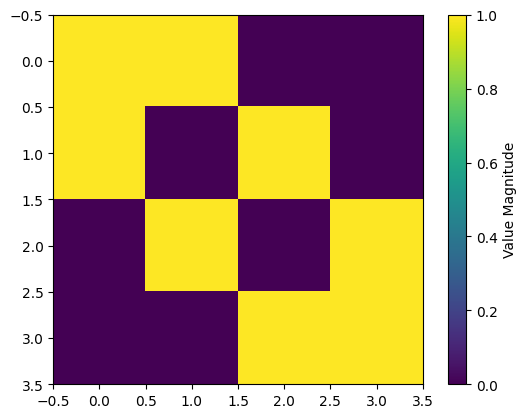

In [2]:
# Construct a transition matrix for the following game:
# a pawn on a 4x4 grid with states s_0 through_15
# |  0 |  1 |  2 |  3 |
# |  4 |  5 |  6 |  7 |
# |  8 |  9 | 10 | 11 |
# | 12 | 13 | 14 | 15 |
# can only move left and right, with impossible moves (i.e., (3, right)) remaining in place.

# The matrix values a_ij should indicate for each starting position i on the grid, how many moves can bring the pawn to position j in one move.

n = 16

# Sub-transition matrix within each row
B = diags([[1]*3, [1]*3], [1, -1], dtype=int).toarray()
B[0,0] = 1
B[-1,-1] = 1

plt.imshow(B, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

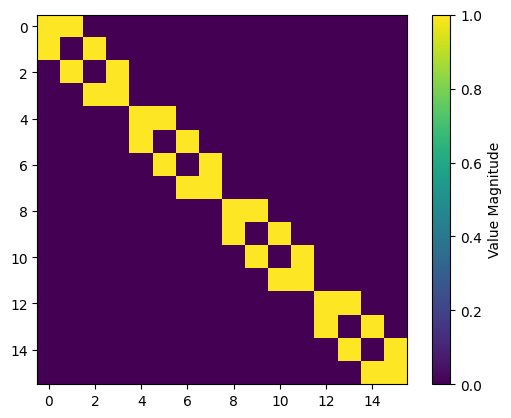

In [3]:
# Stack transition matrices for each row into a block diagonal matrix
A_lr = block_diag(B,B,B,B)
A = A_lr

plt.imshow(A, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

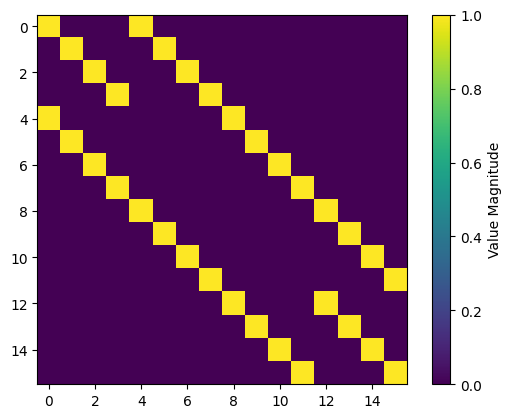

In [4]:
# Construct a transition matrix for the following game:
# a pawn on a 4x4 grid with states s_0 through_15
# |  0 |  1 |  2 |  3 |
# |  4 |  5 |  6 |  7 |
# |  8 |  9 | 10 | 11 |
# | 12 | 13 | 14 | 15 |
# can only move up and down, with impossible moves (i.e., (1, up)) remaining in place
# note this means state k can go to states k +/- 4 if the move is possible

B = eye(4, dtype=int)

A_ud = bmat([[B, B, None, None], 
    [B, None, B, None],
    [None, B, None, B],
    [None, None, B, B]
              ])

plt.imshow(A_ud.toarray(), cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

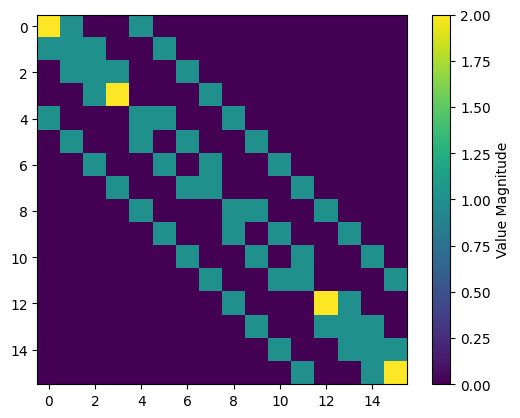

In [5]:
# Add transition matrices for up and down and left right moves on the grid
A = A_lr + A_ud

plt.imshow(A, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

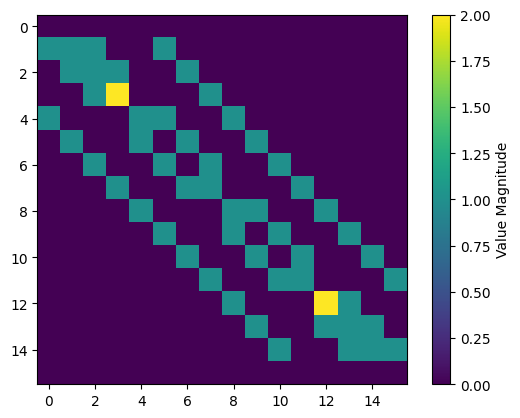

In [6]:
# Modify game so that states 0 and 15 are sinks, i.e. pawns in those states cannot go anywhere
A[0,:] = 0
A[15,:] = 0

plt.imshow(A, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

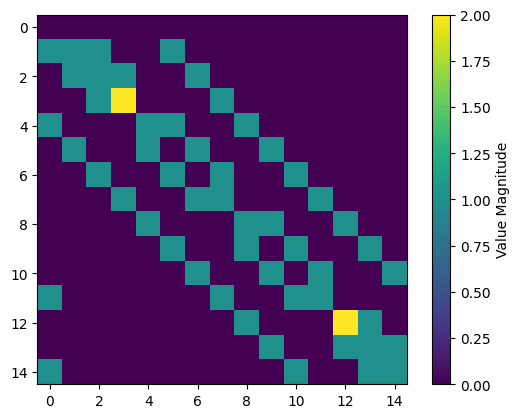

In [7]:
# Modify game so that states 0 and 15 are the same, so that the grid becomes:
# |  0 |  1 |  2 |  3 |
# |  4 |  5 |  6 |  7 |
# |  8 |  9 | 10 | 11 |
# | 12 | 13 | 14 |  0 |

# Add contribution from column 15 to column 0
A[:, 0] += A[:, 15]
# Remove column and row 15
A = A[0:15, 0:15]

plt.imshow(A, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

### Solve linear system for the value function $v_\pi$

In this example $\pi$ is the equiprobable policy, meaning that all possible moves have probability $1/4$ and reard $-1$. Thus the Bellman equation for $v_\pi(\mathbf{s})$ in this case becomes :

$v_\pi(\mathbf{s}) = \frac{1}{4}Av_\pi(\mathbf{s}) - \mathbf{b}$,

where $\mathbf{s}$ is the vector of all possible states $s_0$ throught $s_{14}$ and $\mathbf{b} = (0, 1, ..., 1) \in \mathbb{R}^{15}$

Thus the system we need to solve is 

$( \frac{1}{4}A - I )v_\pi(\mathbf{s}) = \mathbf{b}$

In [8]:
b = np.ones(n-1)
b[0] = 0
v = np.linalg.solve(1/4*A - eye(n-1,n-1), b)

v

array([ -0., -14., -20., -22., -14., -18., -20., -20., -20., -20., -18.,
       -14., -22., -20., -14.])

## Exercise 4.2(a) from book

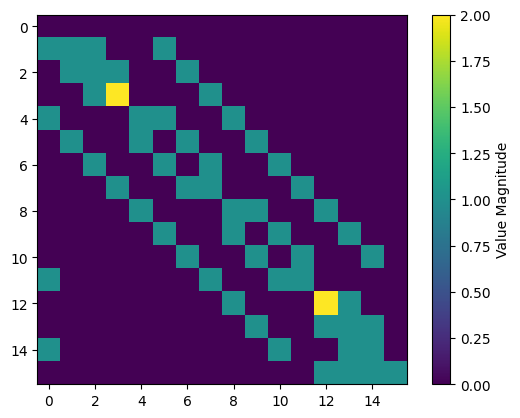

In [9]:
# Modify game so that there's a new state 15 just below state 13
# |  0 |  1 |  2 |  3 |
# |  4 |  5 |  6 |  7 |
# |  8 |  9 | 10 | 11 |
# | 12 | 13 | 14 |  0 |
#      | 15 |
# such that pawns in state 15 move to 12, 13, 14, 15 when moving left, up, right, down respectively
# and all other transitions remain unchanged.

# The matrix of possible moves becomes
A2 = bmat([
    [A, None],
    [None, [1]]
              ]).toarray()
A2[15, 12:15]  = 1

plt.imshow(A2, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

### Solve new linear system for the value function $v_\pi$

This exercise has the same Bellman equation as example 4.1, but using the new transition matrix:

$v_\pi(\mathbf{s}) = \frac{1}{4}A_2v_\pi(\mathbf{s}) - \mathbf{b}$,

where $\mathbf{s}$ is the vector of all possible states $s_0$ throught $s_{15}$ and $\mathbf{b} = (0, 1, ..., 1) \in \mathbb{R}^{16}$

Thus the system we need to solve is 

$( \frac{1}{4}A_2 - I )v_\pi(\mathbf{s}) = \mathbf{b}$

In [10]:
b = np.ones(n)
b[0] = 0
v = np.linalg.solve(1/4*A2 - eye(n,n), b)

v

array([ -0., -14., -20., -22., -14., -18., -20., -20., -20., -20., -18.,
       -14., -22., -20., -14., -20.])

## Exercise 4.2(b) from book

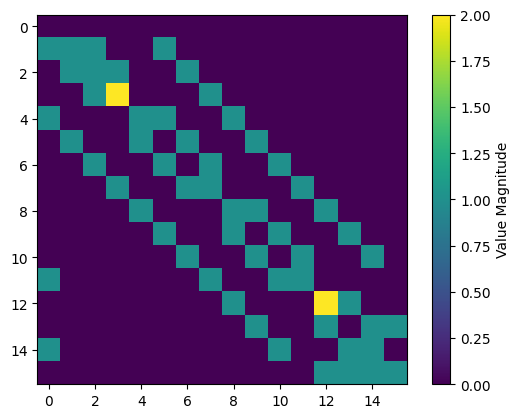

In [11]:
# Modify game so that there's a new state 15 just below state 13
# |  0 |  1 |  2 |  3 |
# |  4 |  5 |  6 |  7 |
# |  8 |  9 | 10 | 11 |
# | 12 | 13 | 14 |  0 |
#      | 15 |
# such that pawns in state 15 move to 12, 13, 14, 15 when moving left, up, right, down respectively,
# and pawns moving down from 13 move to state 15.

# The matrix of possible moves becomes
A3 = A2
A3[13, 13] -= 1
A3[13, 15] += 1

plt.imshow(A3, cmap='viridis')
plt.colorbar(label='Value Magnitude')
plt.show()

### Solve new linear system for the value function $v_\pi$

The linear equation for $v_\pi(\mathbf{s})$ is the same as in part (a), with the new matrix:

$( \frac{1}{4}A_3 - I )v_\pi(\mathbf{s}) = \mathbf{b}$

In [12]:
b = np.ones(n)
b[0] = 0
v = np.linalg.solve(1/4*A3 - eye(n,n), b)

v

array([ -0., -14., -20., -22., -14., -18., -20., -20., -20., -20., -18.,
       -14., -22., -20., -14., -20.])